# MNIST End-to-End — PyTorch

> **Self-contained E2E notebook.** Run top-to-bottom in a fresh kernel. It covers data loading, quality checks, deterministic train/validation/test separation, preprocessing, batching, ANN definition, training, validation, final test evaluation, error analysis, serialization/reload, and inference.

**Lifecycle:** raw MNIST → validate data → split → preprocess → batch → ANN → loss/backprop → validation → final test → metrics → save/reload → inference.

**Architecture:** `784 → 128 → ReLU → 64 → ReLU → 10 logits`.


## 1. Imports, reproducibility, and paths

Seeds make the experiment repeatable. Data and model artifacts are stored under `data/` and `artifacts/`.


In [1]:
from pathlib import Path
import random, urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR, ARTIFACT_DIR = ROOT / "data", ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True); ARTIFACT_DIR.mkdir(exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "device", device)


PyTorch 2.5.1+cpu device cpu


## 2. Load the official MNIST archive and validate it

Both framework notebooks use the exact same `mnist.npz` source. We validate shape, label domain, missingness, and pixel range before modeling. These checks mirror production data contracts.


In [2]:
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_PATH = DATA_DIR / "mnist.npz"
if not MNIST_PATH.exists():
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_full, y_full = data["x_train"], data["y_train"]
    x_test_raw, y_test = data["x_test"], data["y_test"]
assert x_full.shape == (60000, 28, 28) and x_test_raw.shape == (10000, 28, 28)
assert set(np.unique(y_full)) == set(range(10))
assert not np.isnan(x_full.astype("float32")).any()
assert x_full.min() >= 0 and x_full.max() <= 255
print("development:", x_full.shape, y_full.shape)
print("test:", x_test_raw.shape, y_test.shape)
display(pd.Series(y_full).value_counts().sort_index().rename("count").to_frame())


development: (60000, 28, 28) (60000,)
test: (10000, 28, 28) (10000,)


,count
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851
9,5949


## 3. Deterministic train / validation / test separation

The official 10,000-image test set remains untouched until final evaluation. We stratify only the original training set into **50,000 train** and **10,000 validation** examples. Train learns parameters; validation guides development; test is the final acceptance set.


In [3]:
x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    x_full, y_full, test_size=10000, random_state=SEED, stratify=y_full
)
print("train:", x_train_raw.shape, y_train.shape)
print("validation:", x_val_raw.shape, y_val.shape)
print("test:", x_test_raw.shape, y_test.shape)

def preprocess(x):
    return x.reshape(len(x), 784).astype("float32") / 255.0

x_train, x_val, x_test = map(preprocess, [x_train_raw, x_val_raw, x_test_raw])
print("normalized range:", float(x_train.min()), float(x_train.max()))


train: (50000, 28, 28) (50000,)
validation: (10000, 28, 28) (10000,)
test: (10000, 28, 28) (10000,)
normalized range: 0.0 1.0


## 4. Build the PyTorch input pipeline and ANN

The input to the network has shape `[batch, 784]`. The final layer emits **logits**, not probabilities. ReLU provides non-linearity and He/Kaiming-style initialization supports stable ReLU signal propagation.


In [4]:
BATCH_SIZE=256
generator=torch.Generator().manual_seed(SEED)
train_loader=DataLoader(TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train).long()), batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_loader=DataLoader(TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val).long()), batch_size=BATCH_SIZE)
test_loader=DataLoader(TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test).long()), batch_size=BATCH_SIZE)
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(784,128), nn.ReLU(), nn.Linear(128,64), nn.ReLU(), nn.Linear(64,10))
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity="relu"); nn.init.zeros_(layer.bias)
    def forward(self,x): return self.net(x)
model=MNISTMLP().to(device)
criterion=nn.CrossEntropyLoss(); optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
print(model); print("parameters", sum(p.numel() for p in model.parameters()))


MNISTMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
parameters 109386


## 5. Train and validate every epoch

Training performs gradient-based parameter updates. Validation runs after each epoch **without updating parameters**, giving generalization feedback while protecting the final test set.


In [5]:
def run_epoch(loader, training):
    model.train(training); total_loss=0.0; correct=0; total=0
    for features, targets_batch in loader:
        features, targets_batch = features.to(device), targets_batch.to(device)
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits=model(features); loss=criterion(logits, targets_batch)
            if training: loss.backward(); optimizer.step()
        total_loss += loss.item()*len(targets_batch); correct += (logits.argmax(1)==targets_batch).sum().item(); total += len(targets_batch)
    return total_loss/total, correct/total
history=[]
for epoch in range(1,6):
    tl,ta=run_epoch(train_loader,True); vl,va=run_epoch(val_loader,False)
    history.append(dict(epoch=epoch,train_loss=tl,train_accuracy=ta,val_loss=vl,val_accuracy=va))
    print(f"epoch={epoch} train_loss={tl:.4f} train_acc={ta:.4f} val_loss={vl:.4f} val_acc={va:.4f}")


epoch=1 train_loss=0.4450 train_acc=0.8760 val_loss=0.2218 val_acc=0.9372


epoch=2 train_loss=0.1740 train_acc=0.9500 val_loss=0.1608 val_acc=0.9537


epoch=3 train_loss=0.1235 train_acc=0.9644 val_loss=0.1355 val_acc=0.9602


epoch=4 train_loss=0.0968 train_acc=0.9715 val_loss=0.1193 val_acc=0.9653


epoch=5 train_loss=0.0770 train_acc=0.9777 val_loss=0.1066 val_acc=0.9681


## 6. Learning curves and final untouched test evaluation

Training/validation curves expose convergence and overfitting. Only after development is complete do we evaluate the official test set. Accuracy is complemented with per-class precision/recall/F1 and a confusion matrix.


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.444982,0.87600,0.221815,0.9372
1,2,0.174025,0.94998,0.160803,0.9537
2,3,0.123513,0.96438,0.135503,0.9602
3,4,0.096785,0.97150,0.119306,0.9653
4,5,0.077025,0.97770,0.106633,0.9681


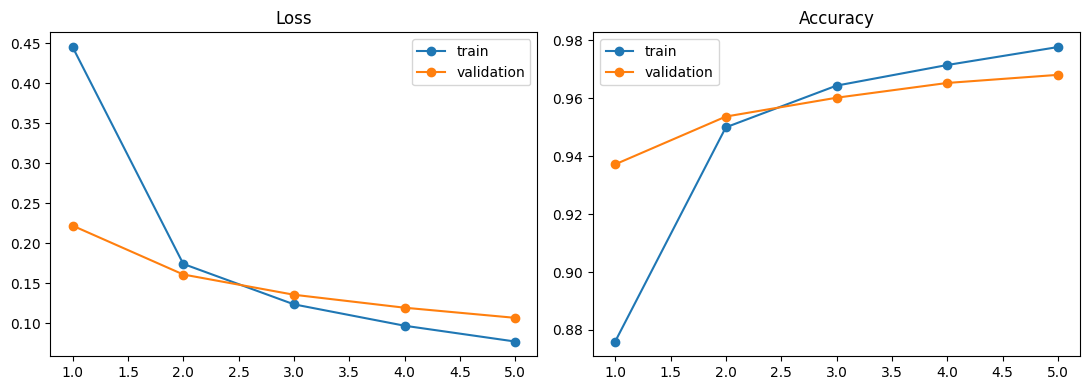

test_loss=0.0944 test_accuracy=0.9712
              precision    recall  f1-score   support

           0     0.9718    0.9847    0.9782       980
           1     0.9825    0.9903    0.9864      1135
           2     0.9795    0.9709    0.9752      1032
           3     0.9536    0.9762    0.9648      1010
           4     0.9706    0.9735    0.9720       982
           5     0.9664    0.9664    0.9664       892
           6     0.9659    0.9749    0.9704       958
           7     0.9716    0.9650    0.9683      1028
           8     0.9788    0.9476    0.9630       974
           9     0.9699    0.9594    0.9646      1009

    accuracy                         0.9712     10000
   macro avg     0.9710    0.9709    0.9709     10000
weighted avg     0.9713    0.9712    0.9712     10000



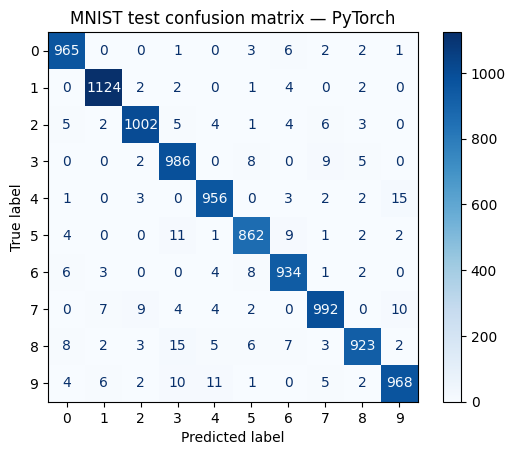

In [6]:
history_df = pd.DataFrame(history)
display(history_df)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df.epoch, history_df.train_loss, marker="o", label="train")
axes[0].plot(history_df.epoch, history_df.val_loss, marker="o", label="validation")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history_df.epoch, history_df.train_accuracy, marker="o", label="train")
axes[1].plot(history_df.epoch, history_df.val_accuracy, marker="o", label="validation")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

test_loss,test_accuracy=run_epoch(test_loader,False)
print(f"test_loss={test_loss:.4f} test_accuracy={test_accuracy:.4f}")
model.eval(); ps=[]; ys=[]
with torch.no_grad():
    for features, labels in test_loader:
        p=torch.softmax(model(features.to(device)),dim=1).cpu().numpy(); ps.append(p); ys.append(labels.numpy())
probs=np.concatenate(ps); targets=np.concatenate(ys); predictions=probs.argmax(1)
print(classification_report(targets,predictions,digits=4))
cm=confusion_matrix(targets,predictions); ConfusionMatrixDisplay(cm).plot(cmap="Blues",values_format="d"); plt.title("MNIST test confusion matrix — PyTorch"); plt.show()


## 7. Error analysis

Aggregate metrics do not explain individual failures. We inspect high-confidence mistakes because confidently wrong predictions are especially risky in automated production decisions.


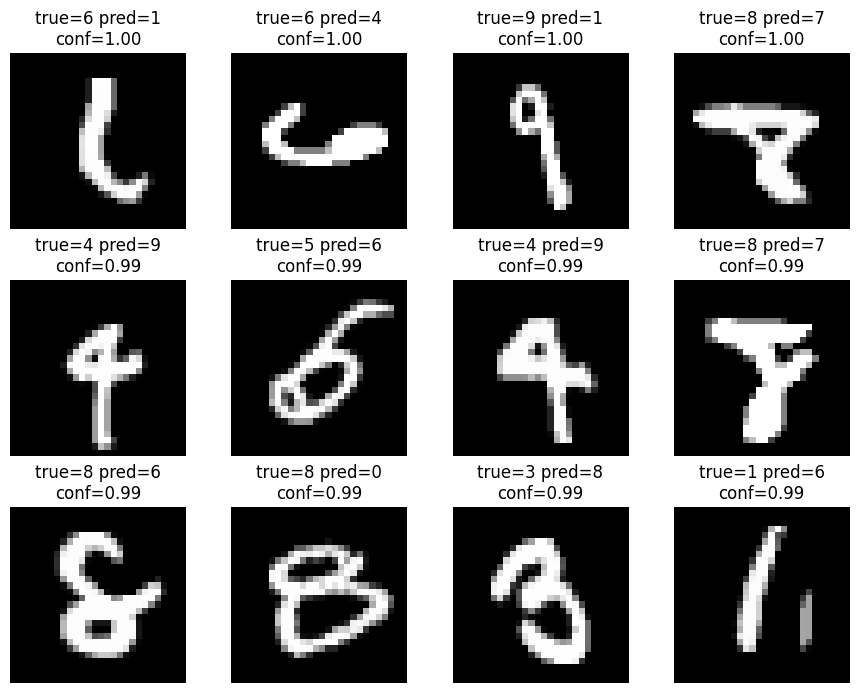

In [7]:
confidence = probs.max(axis=1)
wrong = np.flatnonzero(predictions != targets)
hardest = wrong[np.argsort(confidence[wrong])[-12:]][::-1]
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for idx, ax in zip(hardest, axes.ravel()):
    ax.imshow(x_test_raw[idx], cmap="gray")
    ax.set_title(f"true={targets[idx]} pred={predictions[idx]}\nconf={confidence[idx]:.2f}")
    ax.axis("off")
plt.tight_layout(); plt.show()


## 8. Save, reload, and verify parity

A production artifact must survive process boundaries. We save the trained model, reload it into a fresh object, and verify that predictions are unchanged.


In [8]:
MODEL_PATH=ARTIFACT_DIR/"mnist_pytorch_mlp.pt"
torch.save(model.state_dict(),MODEL_PATH)
reloaded_model=MNISTMLP().to(device)
reloaded_model.load_state_dict(torch.load(MODEL_PATH,map_location=device,weights_only=True)); reloaded_model.eval()
with torch.no_grad():
    a=model(torch.from_numpy(x_test[:32]).to(device)).argmax(1); b=reloaded_model(torch.from_numpy(x_test[:32]).to(device)).argmax(1)
assert torch.equal(a,b); print("reload parity verified:",MODEL_PATH)


reload parity verified: /home/runner/work/awesome-deep-learning-resource/awesome-deep-learning-resource/artifacts/mnist_pytorch_mlp.pt


## 9. Single-sample inference contract

Inference repeats exactly the training preprocessing and returns the predicted class, confidence, and complete probability vector. This is the boundary an API or batch-scoring service would expose.


In [9]:
def predict_one(raw_image, trained_model):
    features=raw_image.reshape(1,784).astype("float32")/255.0
    with torch.no_grad(): p=torch.softmax(trained_model(torch.from_numpy(features).to(device)),dim=1)[0].cpu().numpy()
    cls=int(p.argmax()); return {"predicted_class":cls,"confidence":float(p[cls]),"probabilities":p}
result=predict_one(x_test_raw[0],reloaded_model)
print("true",int(y_test[0]),"predicted",result["predicted_class"],"confidence",round(result["confidence"],4))


true 7 predicted 7 confidence 0.9991


## Completion checklist

- official MNIST provenance and data-quality assertions ✅
- isolated train / validation / test lifecycle ✅
- preprocessing and batching ✅
- ANN architecture and initialization ✅
- explicit optimization/training loop ✅
- epoch-level validation ✅
- final untouched test evaluation ✅
- precision / recall / F1 / confusion matrix ✅
- error analysis ✅
- serialization / reload parity ✅
- production-style single inference function ✅

This is the compact **end-to-end reference implementation**. The larger Manual/PyTorch/TensorFlow branches remain the deep conceptual courses.
